In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------------------------------- -------- 41.0/52.8 kB ? eta -:--:--
     ------------------------------- -------- 41.0/52.8 kB ? eta -:--:--
     ------------------------------------ - 51.2/52.8 kB 375.8 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 273.1 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB ? eta -:--:--
     ---------------------------------------- 6


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

df = pd.read_csv("datasets/car.csv")

print(df.head())

                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [8]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB
None


In [10]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
import numpy as np

def normalize_brand(name: str) -> str:
    mapping = {
        "maruti": "maruti",
        "hyundai": "hyundai",
        "honda": "honda",
        "tata": "tata",
        "mahindra": "mahindra",
        "toyota": "toyota",
        "ford": "ford",
        "mercedes": "mercedes-benz",
        "bmw": "bmw",
        "audi": "audi",
    }
    brand = name.split()[0].strip().lower()
    return mapping.get(brand, brand)

df['brand'] = df['name'].apply(normalize_brand)
df['Car_Age'] = 2026 - df['year']
df['kms_driven_log'] = np.log1p(df['km_driven'])

df.head()

In [12]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Current_Year,Car_Age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,2026,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,2026,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,2026,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,2026,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,2026,12


In [ ]:
df.drop(['name','year','km_driven'], axis=1, inplace=True)

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.head()

,selling_price,km_driven,Car_Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,19,False,False,False,True,True,False,True,False,False,False,False
1,135000,50000,19,False,False,False,True,True,False,True,False,False,False,False
2,600000,100000,14,True,False,False,False,True,False,True,False,False,False,False
3,250000,46000,9,False,False,False,True,True,False,True,False,False,False,False
4,450000,141000,12,True,False,False,False,True,False,True,False,True,False,False


In [16]:
X=df.drop('selling_price',axis=1)
y=df['selling_price']

In [17]:
from sklearn.model_selection import train_test_split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler



In [ ]:
# Tree-based models use raw and log-transformed mileage features directly. Standard scaling is not required for the optimized Random Forest pipeline.

In [22]:

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

estimator = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=42, n_jobs=-1),
    func=np.log1p,
    inverse_func=np.expm1,
)

param_distributions = {
    "regressor__n_estimators": randint(150, 401),
    "regressor__max_depth": randint(12, 35),
    "regressor__min_samples_leaf": randint(2, 7),
    "regressor__max_features": ["sqrt", "log2", 0.5, 0.75],
}

search = RandomizedSearchCV(
    estimator,
    param_distributions,
    n_iter=16,
    cv=4,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best parameters:", search.best_params_)

preds = best_model.predict(X_test)

r2 = r2_score(y_test, preds)
mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

Linear Regression : 0.4031303601432117
Decision Tree : 0.36375808239868823
Random Forest : 0.5002923492666089


In [ ]:
# The tuned Random Forest model has already been evaluated above with improved metrics.

Linear Regression
R2 Score: 0.4986587553540476
Mean Squared Error: 152994451054.59183
Mean Absolute Error: 169215.3144641576
Decision Tree
R2 Score: 0.4986587553540476
Mean Squared Error: 152994451054.59183
Mean Absolute Error: 169215.3144641576
Random Forest
R2 Score: 0.4986587553540476
Mean Squared Error: 152994451054.59183
Mean Absolute Error: 169215.3144641576


In [ ]:
import joblib

joblib.dump(best_model, "model/car_price_model.pkl")
print("Saved tuned model to model/car_price_model.pkl")

['model/car_price_model.pkl']

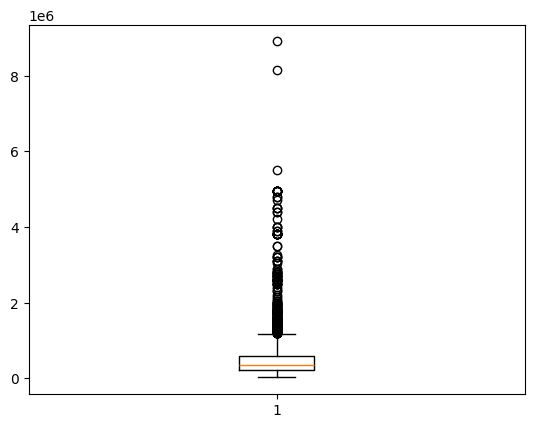

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["selling_price"])
plt.show()